# Exp X — Desvio do Numerador vs Gap do Primo

**Hipótese:** o desvio do numerador em relação à lei de escala
$|\mathcal{F}[R_{\text{primo}}](f_p)| \approx T_{\max}/(2\sqrt{p})$
é controlado pelo gap do primo ao seu vizinho mais próximo.

**Conexão com Nota 27:** o erro residual do numerador é:
$$\epsilon_p = \sum_{q \leq N,\, q \neq p} \frac{1}{\sqrt{q}\,|\log q - \log p|}$$

O termo dominante de $\epsilon_p$ é o primo $q$ mais próximo de $p$,
com distância logarítmica $\delta_p^{\min} = \min_{q\neq p}|\log q - \log p|$.
A Nota 27 estabelece a cota de $\rho_{\min}(k)$ — que controla exatamente
esse mínimo. Primos com gap pequeno têm $\delta_p^{\min}$ pequeno,
$\epsilon_p$ grande, e maior desvio da lei de escala.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime, prevprime, nextprime
from scipy.stats import pearsonr, spearmanr

plt.style.use('dark_background')
C_PRIME = '#00FFB2'
C_COMP  = '#FF4466'
C_GAP   = '#FFB300'
C_ERR   = '#BB44FF'
BG      = '#0D0D1A'

T_MAX, DT = 1500, 0.05
N = 200
t     = np.arange(0.1, T_MAX, DT)
freqs = np.fft.rfftfreq(len(t), d=DT)

def S_m(t, m):
    return -np.cos(t * math.log(m)) / math.sqrt(m)

def f_m(m):
    return math.log(m) / (2 * math.pi)

def amp_em(F, m, w=5):
    idx = np.argmin(np.abs(freqs - f_m(m)))
    lo, hi = max(0, idx-w), min(len(F), idx+w)
    return np.max(F[lo:hi])

print('Pronto.')

Pronto.


## 1. Construir espectro e medir desvios do numerador

In [ ]:
primos = [m for m in range(2, N+1) if isprime(m)]
Rp = sum(S_m(t, p) for p in primos)
Fp = np.abs(np.fft.rfft(Rp)) * DT

dados = []
for p in primos:
    # amplitude medida
    ap = amp_em(Fp, p)
    # amplitude prevista pela lei de escala
    ap_pred = T_MAX / (2 * math.sqrt(p))
    # desvio relativo
    desvio = (ap - ap_pred) / ap_pred

    # gap ao vizinho mais proximo
    p_prev = prevprime(p) if p > 2 else None
    p_next = nextprime(p) if p < N else None
    gap_prev = p - p_prev if p_prev else None
    gap_next = p_next - p if p_next else None
    gap_min  = min(g for g in [gap_prev, gap_next] if g is not None)

    # distancia logaritmica ao vizinho mais proximo
    delta_min = min(
        abs(math.log(p) - math.log(p_prev)) if p_prev else float('inf'),
        abs(math.log(p) - math.log(p_next)) if p_next else float('inf')
    )

    # epsilon_p: soma residual sobre todos os outros primos
    epsilon = sum(
        1 / (math.sqrt(q) * abs(math.log(q) - math.log(p)))
        for q in primos if q != p
    )

    dados.append({
        'p': p, 'ap': ap, 'ap_pred': ap_pred,
        'desvio': desvio,
        'gap_min': gap_min, 'delta_min': delta_min,
        'epsilon': epsilon,
    })

print(f'{"p":>5} {"ap":>10} {"ap_pred":>10} {"desvio%":>9} '
      f'{"gap_min":>9} {"delta_min":>11} {"epsilon":>10}')
print('-'*68)
for d in dados:
    print(f'{d["p"]:>5} {d["ap"]:>10.3f} {d["ap_pred"]:>10.3f} '
          f'{d["desvio"]*100:>9.2f}% {d["gap_min"]:>9} '
          f'{d["delta_min"]:>11.5f} {d["epsilon"]:>10.3f}')

    p         ap    ap_pred   desvio%   gap_min   delta_min    epsilon
--------------------------------------------------------------------
    2    361.109    530.330    -31.91%         1     0.40547      3.919
    3    386.609    433.013    -10.72%         1     0.40547      5.075
    5    313.200    335.410     -6.62%         2     0.33647      5.670
    7    188.014    283.473    -33.67%         2     0.33647      6.062
   11    166.946    226.134    -26.17%         2     0.16705      7.338
   13    177.194    208.013    -14.82%         2     0.16705      7.939
   17    148.214    181.902    -18.52%         2     0.11123      8.945
   19    166.490    172.062     -3.24%         2     0.11123      9.287
   23     99.655    156.386    -36.28%         4     0.19106      8.594
   29    130.414    139.272     -6.36%         2     0.06669     10.595
   31    122.227    134.704     -9.26%         2     0.06669     10.943
   37    122.799    123.299     -0.41%         4     0.10265     10.

## 2. Correlações: desvio vs gap, $\delta_{\min}$, $\epsilon_p$

In [ ]:
desvios   = np.array([d['desvio']    for d in dados])
gaps      = np.array([d['gap_min']   for d in dados])
deltas    = np.array([d['delta_min'] for d in dados])
epsilons  = np.array([d['epsilon']   for d in dados])
ps        = np.array([d['p']         for d in dados])

c1, _ = pearsonr(gaps,     desvios)
c2, _ = pearsonr(deltas,   desvios)
c3, _ = pearsonr(epsilons, desvios)
c4, _ = spearmanr(gaps,    desvios)
c5, _ = pearsonr(1/deltas, np.abs(desvios))

print('Correlacoes com o desvio relativo do numerador:')
print(f'  corr(gap_min, desvio)          = {c1:>8.4f}  [Pearson]')
print(f'  corr(delta_min, desvio)        = {c2:>8.4f}  [Pearson]')
print(f'  corr(epsilon_p, desvio)        = {c3:>8.4f}  [Pearson]')
print(f'  corr(gap_min, desvio)          = {c4:>8.4f}  [Spearman]')
print(f'  corr(1/delta_min, |desvio|)    = {c5:>8.4f}  [hipotese principal]')

print(f'\nDesvio medio por tamanho de gap:')
print(f'{"gap":>6} {"n":>4} {"desvio_medio%":>15} {"desvio_std%":>13}')
print('-'*42)
for g in sorted(set(gaps)):
    idx = gaps == g
    if idx.sum() >= 2:
        print(f'{g:>6} {idx.sum():>4} '
              f'{desvios[idx].mean()*100:>15.3f} '
              f'{desvios[idx].std()*100:>13.3f}')

Correlacoes com o desvio relativo do numerador:
  corr(gap_min, desvio)          =   0.0852  [Pearson]
  corr(delta_min, desvio)        =  -0.3253  [Pearson]
  corr(epsilon_p, desvio)        =   0.3387  [Pearson]
  corr(gap_min, desvio)          =   0.1462  [Spearman]
  corr(1/delta_min, |desvio|)    =  -0.3326  [hipotese principal]

Desvio medio por tamanho de gap:
   gap    n   desvio_medio%   desvio_std%
------------------------------------------
     1    2         -21.313        10.596
     2   28         -12.214        11.062
     4   12         -10.712        12.077
     6    4         -11.650        13.480


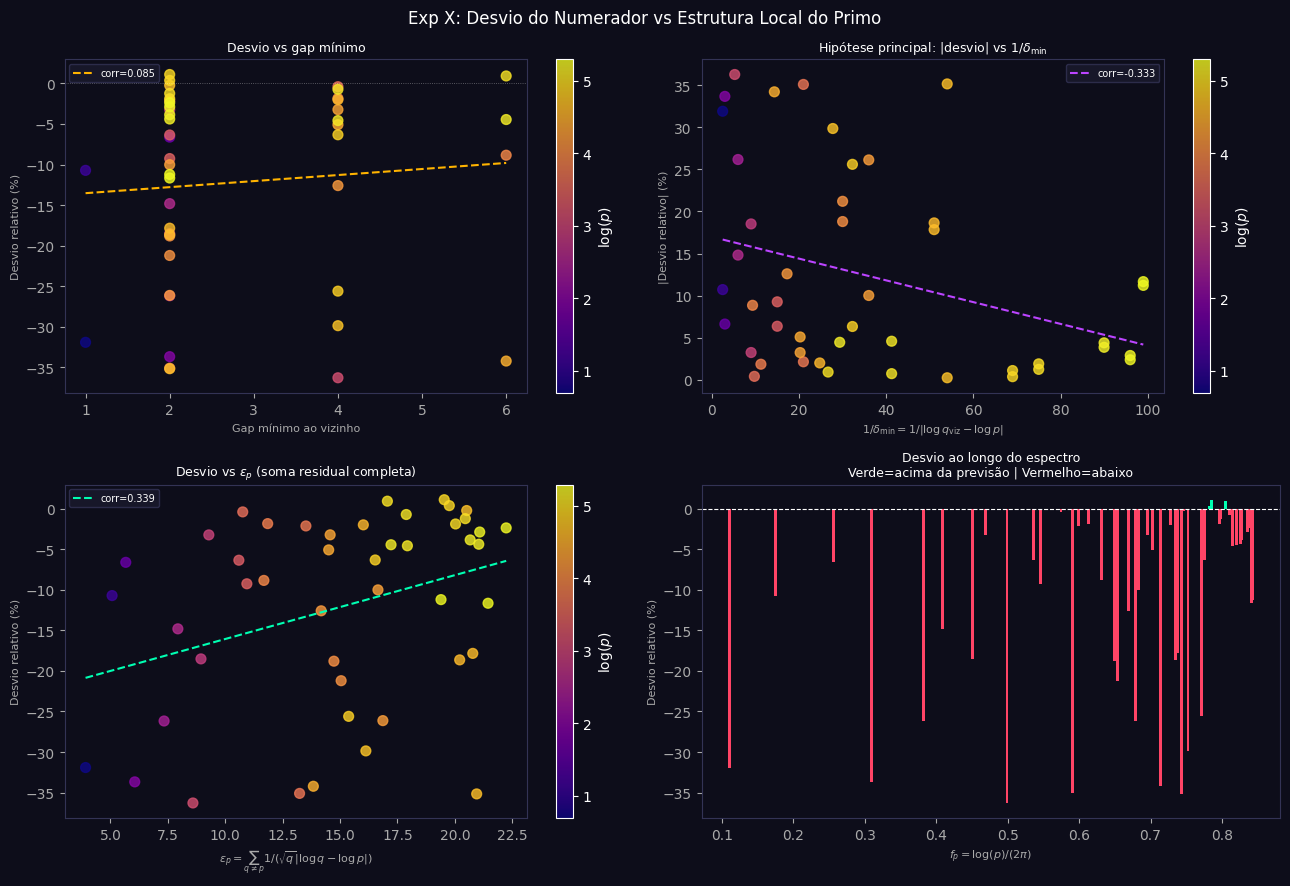

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor(BG)
fig.suptitle('Exp X: Desvio do Numerador vs Estrutura Local do Primo',
             color='white', fontsize=12)

# 1. Desvio vs gap_min
ax = axes[0][0]; ax.set_facecolor(BG)
sc = ax.scatter(gaps, desvios*100, c=np.log(ps),
                cmap='plasma', s=50, alpha=0.8)
plt.colorbar(sc, ax=ax, label='$\\log(p)$')
z = np.polyfit(gaps, desvios*100, 1)
x_l = np.linspace(gaps.min(), gaps.max(), 100)
ax.plot(x_l, np.polyval(z, x_l), color=C_GAP, lw=1.5, ls='--',
        label=f'corr={c1:.3f}')
ax.axhline(0, color='white', lw=0.6, ls=':', alpha=0.4)
ax.set_xlabel('Gap mínimo ao vizinho', color='#AAAAAA', fontsize=8)
ax.set_ylabel('Desvio relativo (%)', color='#AAAAAA', fontsize=8)
ax.set_title('Desvio vs gap mínimo', color='white', fontsize=9)
ax.legend(fontsize=7, facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# 2. |Desvio| vs 1/delta_min (hipotese principal)
ax = axes[0][1]; ax.set_facecolor(BG)
sc2 = ax.scatter(1/deltas, np.abs(desvios)*100, c=np.log(ps),
                 cmap='plasma', s=50, alpha=0.8)
plt.colorbar(sc2, ax=ax, label='$\\log(p)$')
z2 = np.polyfit(1/deltas, np.abs(desvios)*100, 1)
x_l2 = np.linspace((1/deltas).min(), (1/deltas).max(), 100)
ax.plot(x_l2, np.polyval(z2, x_l2), color=C_ERR, lw=1.5, ls='--',
        label=f'corr={c5:.3f}')
ax.set_xlabel('$1/\\delta_{\\min} = 1/|\\log q_{\\text{viz}} - \\log p|$',
              color='#AAAAAA', fontsize=8)
ax.set_ylabel('|Desvio relativo| (%)', color='#AAAAAA', fontsize=8)
ax.set_title('Hipótese principal: $|\\text{desvio}|$ vs $1/\\delta_{\\min}$',
             color='white', fontsize=9)
ax.legend(fontsize=7, facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# 3. Desvio vs epsilon_p
ax = axes[1][0]; ax.set_facecolor(BG)
sc3 = ax.scatter(epsilons, desvios*100, c=np.log(ps),
                 cmap='plasma', s=50, alpha=0.8)
plt.colorbar(sc3, ax=ax, label='$\\log(p)$')
z3 = np.polyfit(epsilons, desvios*100, 1)
x_l3 = np.linspace(epsilons.min(), epsilons.max(), 100)
ax.plot(x_l3, np.polyval(z3, x_l3), color=C_PRIME, lw=1.5, ls='--',
        label=f'corr={c3:.3f}')
ax.set_xlabel('$\\epsilon_p = \\sum_{q\\neq p} 1/(\\sqrt{q}|\\log q - \\log p|)$',
              color='#AAAAAA', fontsize=8)
ax.set_ylabel('Desvio relativo (%)', color='#AAAAAA', fontsize=8)
ax.set_title('Desvio vs $\\epsilon_p$ (soma residual completa)',
             color='white', fontsize=9)
ax.legend(fontsize=7, facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# 4. Desvio ao longo do espectro (posicao)
ax = axes[1][1]; ax.set_facecolor(BG)
fqs_p = [f_m(p) for p in ps]
colors_gap = plt.cm.RdYlGn([g/gaps.max() for g in gaps])
ax.bar(fqs_p, desvios*100, width=0.004,
       color=[C_PRIME if d >= 0 else C_COMP for d in desvios],
       edgecolor='none')
ax.axhline(0, color='white', lw=0.8, ls='--')
ax.set_xlabel('$f_p = \\log(p)/(2\\pi)$', color='#AAAAAA', fontsize=8)
ax.set_ylabel('Desvio relativo (%)', color='#AAAAAA', fontsize=8)
ax.set_title('Desvio ao longo do espectro\nVerde=acima da previsão | Vermelho=abaixo',
             color='white', fontsize=9)
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

## 3. Conexão com $\rho_{\min}$ da Nota 27

A Nota 27 estabelece que $\rho_{\min}(k) \sim c/(2^{k+1}(k+1)\log 2)$,
onde $\rho_{\min}$ é a distância mínima de um primo ao reticulado
dos primos menores. Para primos no bloco $A_k = [2^k, 2^{k+1}]$,
$\delta_{\min} \approx \rho_{\min}(k)$.

Verificamos se o desvio do numerador segue a cota da Nota 27.

In [ ]:
def rho_min_nota27(k, c=0.09):
    """Cota tight da Nota 27: rho_min(k) ~ c / (2^(k+1) * (k+1) * log2)"""
    return c / (2**(k+1) * (k+1) * math.log(2))

print('Conexao com Nota 27:')
print(f'{"p":>5} {"bloco_k":>8} {"delta_min":>11} '
      f'{"rho_min(k)":>12} {"razao":>8} {"desvio%":>9}')
print('-'*60)

for d in dados:
    p = d['p']
    k = int(math.floor(math.log2(p)))
    rho = rho_min_nota27(k)
    razao = d['delta_min'] / rho if rho > 0 else float('inf')
    print(f'{p:>5} {k:>8} {d["delta_min"]:>11.5f} '
          f'{rho:>12.6f} {razao:>8.2f} {d["desvio"]*100:>9.3f}%')

# Correlacao entre razao delta/rho e desvio
razoes_rho = []
for d in dados:
    p = d['p']
    k = int(math.floor(math.log2(p)))
    rho = rho_min_nota27(k)
    razoes_rho.append(d['delta_min'] / rho)

razoes_rho = np.array(razoes_rho)
c_rho, _ = pearsonr(razoes_rho, desvios)
print(f'\ncorr(delta_min/rho_min, desvio) = {c_rho:.4f}')
print('(positivo = primos com delta grande relativo a rho_min tem desvio maior)')

Conexao com Nota 27:
    p  bloco_k   delta_min   rho_min(k)    razao   desvio%
------------------------------------------------------------
    2        1     0.40547     0.016230    24.98   -31.909%
    3        1     0.40547     0.016230    24.98   -10.717%
    5        2     0.33647     0.005410    62.19    -6.622%
    7        2     0.33647     0.005410    62.19   -33.675%
   11        3     0.16705     0.002029    82.34   -26.174%
   13        3     0.16705     0.002029    82.34   -14.816%
   17        4     0.11123     0.000812   137.06   -18.520%
   19        4     0.11123     0.000812   137.06    -3.238%
   23        4     0.19106     0.000812   235.43   -36.276%
   29        4     0.06669     0.000812    82.18    -6.360%
   31        4     0.06669     0.000812    82.18    -9.263%
   37        5     0.10265     0.000338   303.59    -0.405%
   41        5     0.04763     0.000338   140.86   -35.095%
   43        5     0.04763     0.000338   140.86    -2.136%
   47        5     